In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.4904351e-05)  # constant metallicity (Z=0.02)
zmet = 1


ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

ssp_data.ssp_flux.shape

Z = 10**-4.4904351e-05
print(Z)

0.9998966092559682


In [2]:
import json
import jax.numpy as jnp
import numpy as np          # only for dtype and IO, not computation

class Observation:

    _kind = "observation"
    logify_spectrum = False
    alias = {}
    _meta = ("kind", "name")
    _data = ("wavelength", "flux", "uncertainty", "mask")

    def __init__(self,
                 flux=None,
                 uncertainty=None,
                 mask=slice(None),
                 noise=None,
                 name=None,
                 **kwargs):

        # convert to JAX arrays
        self.flux = None if flux is None else jnp.asarray(flux)
        self.uncertainty = None if uncertainty is None else jnp.asarray(uncertainty)

        # handle initial mask
        if isinstance(mask, slice):
            # convert slice → boolean mask
            if self.flux is None:
                self.mask = jnp.array([], dtype=bool)
            else:
                m = np.zeros(len(self.flux), dtype=bool)
                m[mask] = True
                self.mask = jnp.asarray(m)
        else:
            self.mask = jnp.asarray(mask, dtype=bool)

        self.noise = noise

        # name
        if name is None:
            addr = f"{id(self):04x}"
            self.name = f"{self.kind[:5]}-{addr[:6]}"
        else:
            self.name = name

        # validate + auto-mask
        self.rectify()

    # ------------------------------------------------------------
    def __str__(self):
        info = [
            f"Observation object: {self.kind} ({self.name})",
            f"  ndata         : {self.ndata}",
            f"  ndof          : {self.ndof}",
            f"  wavelength min: {None if not hasattr(self, 'wavelength') or self.wavelength is None else float(jnp.min(self.wavelength))}",
            f"  wavelength max: {None if not hasattr(self, 'wavelength') or self.wavelength is None else float(jnp.max(self.wavelength))}",
            f"  masked points : {int(jnp.sum(~self.mask))} / {self.ndata}",
            f"  flux finite   : {int(jnp.sum(jnp.isfinite(self.flux)))} / {self.ndata}",
            f"  unc finite    : {int(jnp.sum(jnp.isfinite(self.uncertainty)))} / {self.ndata}",
            f"  noise model   : {self.noise.__class__.__name__}"
        ]
        return "\n".join(info)

    def __getitem__(self, item):
        k = self.alias.get(item, item)
        return getattr(self, k)

    def get(self, item, default):
        try:
            return self[item]
        except AttributeError:
            return default


    # ------------------------------------------------------------
    def rectify(self):
        """
        Validation and automatic masking (host-side).
        JAX arrays are OK here — no JIT paths.
        """
        n = self.__repr__

        if self.flux is None:
            print(f"{n} has no data")
            self.wavelength = None
            return

        # Ensure 1D arrays
        assert self.flux.ndim == 1, "flux must be 1D"
        assert self.uncertainty.ndim == 1, "uncertainty must be 1D"
        assert len(self.flux) == len(self.uncertainty), \
            "flux and uncertainty lengths differ"

        if self.wavelength is not None:
            assert self.wavelength.ndim == 1, "wavelength must be 1D"
            assert len(self.wavelength) == len(self.flux), \
                "wavelength length mismatch"

        # update mask using JAX
        self._automask()

        assert self.ndof > 0, "no valid unmasked datapoints"
        assert hasattr(self, "noise")

    # ------------------------------------------------------------
    def _automask(self):
        """JAX-compatible auto-mask; no numpy ops."""
        if self.flux is None:
            return

        # base mask
        base = self.mask

        # new valid mask
        valid = (
            jnp.isfinite(self.flux) &
            jnp.isfinite(self.uncertainty) &
            (self.uncertainty > 0)
        )

        self.mask = base & valid


    # ------------------------------------------------------------
    @property
    def kind(self):
        return self._kind

    @property
    def ndof(self):
        return int(jnp.sum(self.mask))

    @property
    def ndata(self):
        return 0 if self.flux is None else len(self.flux)

    @property
    def wave_min(self):
        return None if self.wavelength is None else float(jnp.min(self.wavelength))

    @property
    def wave_max(self):
        return None if self.wavelength is None else float(jnp.max(self.wavelength))

    @property
    def metadata(self):
        meta = {m: getattr(self, m) for m in self._meta}
        if "filternames" in meta:
            meta["filters"] = ",".join(meta["filternames"])
        return meta

    # ------------------------------------------------------------
    def to_struct(self, data_dtype=np.float32):
        """
        Needs numpy structured array → convert jax → numpy
        (This is pure IO; safe.)
        """
        # force auto-mask to run
        self._automask()

        cols = []
        for c in self._data:
            dat = getattr(self, c)
            if dat is None:
                continue
            dat_np = np.asarray(dat)
            if len(dat_np) != self.ndata:
                continue
            cols.append((c, dat_np.dtype))

        dtype = np.dtype(cols)
        struct = np.zeros(self.ndata, dtype=dtype)

        for c in dtype.names:
            struct[c] = np.asarray(getattr(self, c))

        return struct

    def to_fits(self, filename=""):
        from astropy.io import fits
        hdus = fits.HDUList([
            fits.PrimaryHDU(),
            fits.BinTableHDU(self.to_struct())
        ])
        for hdu in hdus:
            hdu.header.update(self.metadata)
        if filename:
            hdus.writeto(filename, overwrite=True)

    def to_h5_dataset(self, handle):
        dset = handle.create_dataset(self.name, data=self.to_struct())
        dset.attrs.update(self.metadata)

    def to_json(self):
        obs = {m: getattr(self, m) for m in self._meta + self._data}
        convert = {k: (np.asarray(v).tolist() if isinstance(v, jnp.ndarray)
                       else v)
                   for k, v in obs.items()}
        return json.dumps(convert)

    @property
    def maggies_to_nJy(self):
        return 1e9 * 3631.0


# =====================================================================
# Subclass: PHOTOMETRY (unchanged API, JAX arrays inside)
# =====================================================================

class Photometry(Observation):

    _kind = "photometry"
    alias = dict(maggies="flux",
                 maggies_unc="uncertainty",
                 filters="filters",
                 phot_mask="mask")
    _meta = ("kind", "name", "filternames")

    def __init__(self, filters=[],
                 name=None,
                 **kwargs):

        self.set_filters(filters)
        super().__init__(name=name, **kwargs)

    def set_filters(self, filters):
        if (len(filters) == 0) or (filters is None):
            self.filters = filters
            self.filternames = []
            self.filterset = None
            return

        try:
            self.filternames = [f.name for f in filters]
        except AttributeError:
            self.filternames = filters

        self.filterset = FilterSet(self.filternames)
        self.filters = [f for f in self.filterset.filters]

    @property
    def wavelength(self):
        # convert to JAX array later if needed
        return jnp.asarray([f.wave_effective for f in self.filters])
    
    def predict_from_spec(self, wave, spec):
        return self.filterset.get_sed_maggies(wave, spec)
    



import jax
import jax.numpy as jnp
from jax import tree_util


@tree_util.register_pytree_node_class
class Photometry(Observation):

    _kind = "photometry"
    alias = dict(maggies="flux",
                 maggies_unc="uncertainty",
                 filters="filters",
                 phot_mask="mask")
    _meta = ("kind", "name", "filternames")

    # ---------------------------------------------------------
    # PyTree registration: mark filterset as STATIC
    # ---------------------------------------------------------
    def tree_flatten(self):
        # JAX-traceable (dynamic) children
        children = ()

        # Static (non-traceable) Python objects:
        aux = dict(
            filternames=self.filternames,
            filterset=self.filterset,
            filters=self.filters,
            name=self.name,
        )
        return children, aux

    @classmethod
    def tree_unflatten(cls, aux, children):
        obj = object.__new__(cls)

        # Restore static members
        obj.filternames = aux["filternames"]
        obj.filterset  = aux["filterset"]
        obj.filters    = aux["filters"]
        obj.name       = aux["name"]

        return obj

    # ---------------------------------------------------------
    # Normal initialization
    # ---------------------------------------------------------
    def __init__(self, filters=[], name=None, **kwargs):

        self.set_filters(filters)
        super().__init__(name=name, **kwargs)

    # ---------------------------------------------------------
    # Use your original FilterSet logic unchanged
    # ---------------------------------------------------------
    def set_filters(self, filters):
        if (len(filters) == 0) or (filters is None):
            self.filters = filters
            self.filternames = []
            self.filterset = None
            return

        try:
            self.filternames = [f.name for f in filters]
        except AttributeError:
            self.filternames = filters

        self.filterset = FSjax(self.filternames)
        self.filters = [f for f in self.filterset.filters]

    @property
    def wavelength(self):
        # convert to JAX array later if needed
        return jnp.asarray([f.wave_effective for f in self.filters])

    # ---------------------------------------------------------
    # JIT-compatible: filterset is static, so method works with jit(static_argnums=(0,))
    # ---------------------------------------------------------
    def predict_from_spec(self, wave, spec):
        return self.filterset.get_sed_maggies(wave, spec)

In [97]:
class ListNode:
     def __init__(self, val=0, next=None):
         self.val = val
         self.next = next

l1 = ListNode(2, ListNode(4, ListNode(3)))
l2 = ListNode(5, ListNode(6, ListNode(4)))


rest = 0
answer = []

while l1 or l2 is not None:
    try:
        v1 = l1.val
        l1 = l1.next
    except:
        v1 = 0
    try:
        v2 = l2.val
        l2 = l2.next
    except:
        v2 = 0

    print(v2, v1, rest)

    sumi = v1 + v2 + rest
    if sumi > 9:
        rest = sumi//10
        answer.append(sumi % 10)
    else:
        answer.append(sumi)

for i, num in enumerate(answer):
    if i == 0:
        ls = ListNode(num)
    else:
        ls = ListNode(num, ls)
print(ls.val)
print(ls.next.val)
print(ls.next.next.val)

5 2 0
6 4 0
4 3 1
8
0
7


In [105]:
"abcabcbb" < "abcabc"

False

In [ ]:

def addTwoNumbers(self, l1, l2):
    answer = []
    rest = 0
    
    for i, j in zip(l1, l2):
            if i+j+rest > 9:
                rest = i+j+rest - 9
                answer.append(0)
            else:
                answer.append(i+j+rest)
    return(answer[::-1])



addTwoNumbers(None, [2,4,3], [5,6,4, 1])

[8, 0, 7]

In [40]:
l1= [2,4,3]
txt = ''
for i in l1[::-1]:
    txt += str(i)
n1 = int(txt)
n1

342

In [ ]:
nums = [3, 2, 4]
target = 4

≈

In [3]:
from sedpy_jax.observate import FilterSet as FSjax
import jax.numpy as jnp
import numpy as np

# -------------------------------------------------------------
# Import your rewritten Observation & Photometry classes
# -------------------------------------------------------------
# (Assume the JAX-compatible Observation / Photometry classes are in the namespace)

# -------------------------------------------------------------
# 1. Create your real filter set
# -------------------------------------------------------------
fset = FSjax([
    'sdss_u0', 'sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0',
    'wise_w1', 'wise_w2',
    'jwst_f150w', 'jwst_f200w', 'jwst_f277w', 'jwst_f356w', 'jwst_f444w'
])

# Pull the filter names from your filter set (your Photometry class expects names)
filternames = [f.name for f in fset.filters]

print("Loaded filters:", filternames)

Loaded filters: ['sdss_u0', 'sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0', 'wise_w1', 'wise_w2', 'jwst_f150w', 'jwst_f200w', 'jwst_f277w', 'jwst_f356w', 'jwst_f444w']


<Axes: title={'center': 'FilterSet Transmission Curves'}, xlabel='Wavelength [Å]', ylabel='Transmission'>

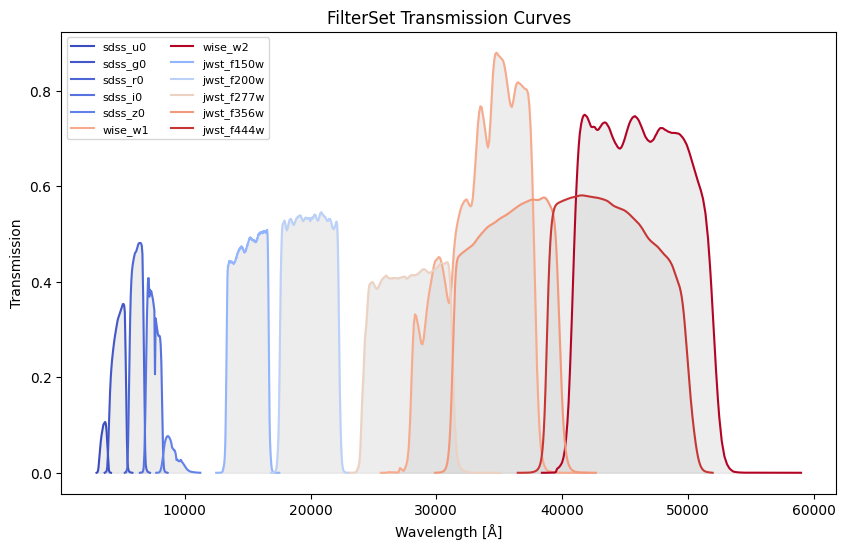

In [4]:
fset.display()

Using combined (binwise + diffuse) dust attenuation.
Initializing Dust attenuation model...
Initializing DiffuseDust model...
Dust initialization complete.
Get spectrum with dust attenuation, without nebular contribution, and without dust emission.
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


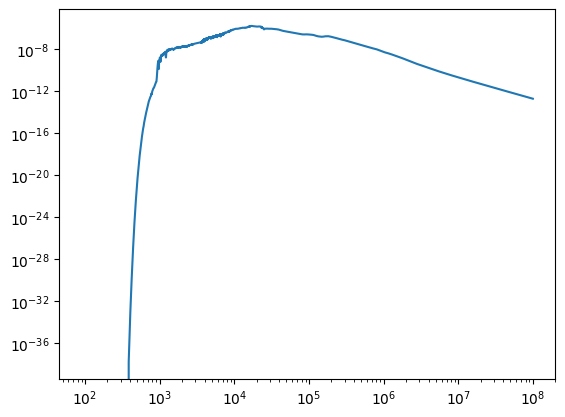

In [5]:
csp = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)

# --- Compile the function, marking `csp` as static
run_spectrum_jit = jit(run_spectrum, static_argnums=0)


spec = run_spectrum_jit(csp, csp.theta_init)
plt.loglog(csp.wave, spec)


# Make mock photometry

In [6]:
def get_maggies(fset, flux, sourcewave):
    return fset.get_sed_maggies(flux, sourcewave)

# --- Compile the function, marking `fset` as static
get_maggies_jit = jit(get_maggies, static_argnums=0)


In [7]:
maggies_flux = get_maggies_jit(fset, spec, csp.wave)
wavelength = [f.wave_effective for f in fset.filters]

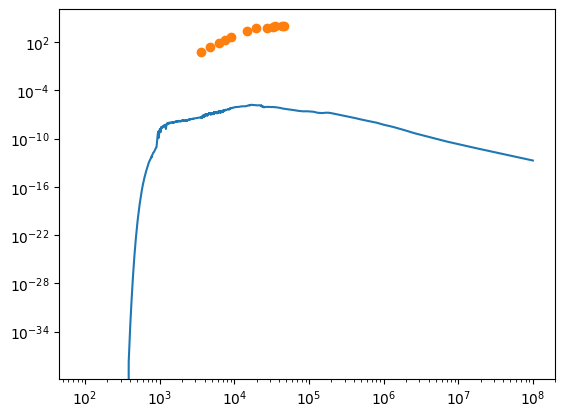

In [8]:
plt.loglog(csp.wave, spec)
plt.loglog(wavelength, maggies_flux, 'o')

In [9]:
n = len(filternames)
flux = jnp.array(maggies_flux)     # maggies
unc  = jnp.asarray(0.1 * flux)                              # 10% fractional error
mask = jnp.ones(n, dtype=bool)                              # all good

# -------------------------------------------------------------
# 3. Build Photometry object
# -------------------------------------------------------------
phot = Photometry(
    filters=filternames,
    flux=flux,
    uncertainty=unc,
    mask=mask,
    name="test_photometry"
)

In [10]:


# -------------------------------------------------------------
# 4. Inspect what the object is doing
# -------------------------------------------------------------
print("\n--- Photometry Object Summary ---")
print("Name          :", phot.name)
print("Kind          :", phot.kind)
print("Ndata         :", phot.ndata)
print("Ndof          :", phot.ndof)

print("\nEffective wavelengths:")
print(np.asarray(phot.wavelength))

print("\nFlux:")
print(np.asarray(phot.flux))

print("\nMask:")
print(np.asarray(phot.mask))

# -------------------------------------------------------------
# 5. Test structured output (numpy structured array)
# -------------------------------------------------------------
struct = phot.to_struct()
print("\nStructured table dtype:", struct.dtype)
print("First row:", struct[0])

# -------------------------------------------------------------
# 6. Test JSON serialization
# -------------------------------------------------------------
js = phot.to_json()
print("\nJSON serialization example (truncated):")
print(js[:200], "...")


--- Photometry Object Summary ---
Name          : test_photometry
Kind          : photometry
Ndata         : 12
Ndof          : 12

Effective wavelengths:
[ 3545.9524  4669.462   6155.554   7471.4775  8917.27   33460.9
 45952.04   14944.23   19781.168  27612.021  35483.457  43787.816 ]

Flux:
[5.5527821e+00 2.4801561e+01 7.3874199e+01 1.7625114e+02 4.2711279e+02
 8.5951973e+03 1.0439989e+04 2.6297339e+03 5.2162388e+03 6.2089219e+03
 9.2657949e+03 1.0312595e+04]

Mask:
[ True  True  True  True  True  True  True  True  True  True  True  True]

Structured table dtype: [('wavelength', '<f4'), ('flux', '<f4'), ('uncertainty', '<f4'), ('mask', '?')]
First row: (3545.9524, 5.552782, 0.55527824, True)

JSON serialization example (truncated):
{"kind": "photometry", "name": "test_photometry", "filternames": ["sdss_u0", "sdss_g0", "sdss_r0", "sdss_i0", "sdss_z0", "wise_w1", "wise_w2", "jwst_f150w", "jwst_f200w", "jwst_f277w", "jwst_f356w", " ...


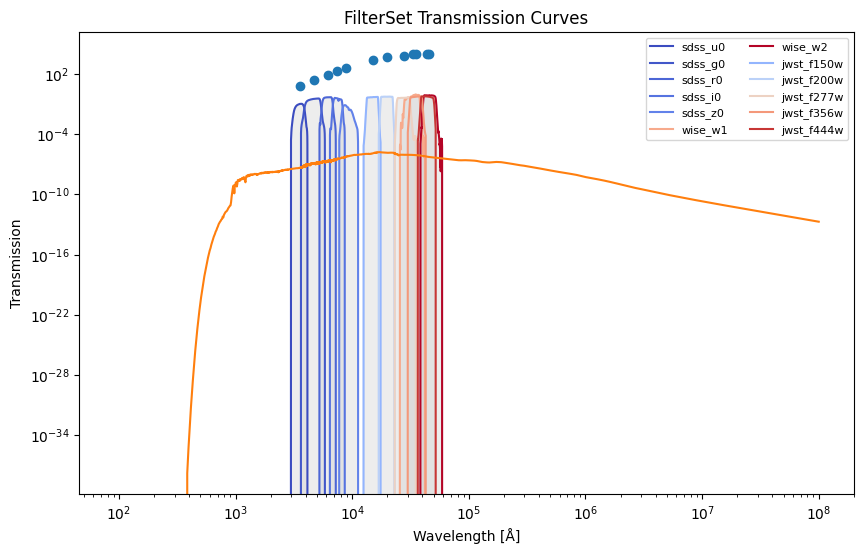

In [11]:
fset.display()

plt.errorbar(phot.wavelength, phot.flux, yerr=phot.uncertainty, fmt='o')
plt.loglog(csp.wave, spec)

In [12]:
phot.to_struct()

array([( 3545.9524, 5.5527821e+00, 5.5527824e-01,  True),
       ( 4669.462 , 2.4801561e+01, 2.4801562e+00,  True),
       ( 6155.554 , 7.3874199e+01, 7.3874202e+00,  True),
       ( 7471.4775, 1.7625114e+02, 1.7625114e+01,  True),
       ( 8917.27  , 4.2711279e+02, 4.2711281e+01,  True),
       (33460.9   , 8.5951973e+03, 8.5951971e+02,  True),
       (45952.04  , 1.0439989e+04, 1.0439989e+03,  True),
       (14944.23  , 2.6297339e+03, 2.6297339e+02,  True),
       (19781.168 , 5.2162388e+03, 5.2162390e+02,  True),
       (27612.021 , 6.2089219e+03, 6.2089221e+02,  True),
       (35483.457 , 9.2657949e+03, 9.2657953e+02,  True),
       (43787.816 , 1.0312595e+04, 1.0312595e+03,  True)],
      dtype=[('wavelength', '<f4'), ('flux', '<f4'), ('uncertainty', '<f4'), ('mask', '?')])

In [13]:
from ceridwen.observation import Photometry

In [14]:
phot = Photometry(flux = maggies_flux,
                  uncertainty = 0.1 * maggies_flux,
                  filters = filternames,
                  name = "test_photometry")

In [15]:
phot.flux

Array([5.5527821e+00, 2.4801561e+01, 7.3874199e+01, 1.7625114e+02,
       4.2711279e+02, 8.5951973e+03, 1.0439989e+04, 2.6297339e+03,
       5.2162388e+03, 6.2089219e+03, 9.2657949e+03, 1.0312595e+04],      dtype=float32)

In [16]:
import h5py

with h5py.File("observations.h5", "w") as handle:
    phot.to_h5_dataset(handle)

In [17]:
phot.metadata

{'kind': 'photometry',
 'name': 'test_photometry',
 'filternames': ['sdss_u0',
  'sdss_g0',
  'sdss_r0',
  'sdss_i0',
  'sdss_z0',
  'wise_w1',
  'wise_w2',
  'jwst_f150w',
  'jwst_f200w',
  'jwst_f277w',
  'jwst_f356w',
  'jwst_f444w'],
 'filters': 'sdss_u0,sdss_g0,sdss_r0,sdss_i0,sdss_z0,wise_w1,wise_w2,jwst_f150w,jwst_f200w,jwst_f277w,jwst_f356w,jwst_f444w'}

In [18]:
phot.filterset

                   FilterSet Summary                    
┏━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┓
┃ Index ┃ Name       ┃ λ_eff [Å] ┃ Width [Å] ┃ AB→Vega ┃
┡━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━┩
│ 0     │ sdss_u0    │ 3546.0    │ 558.6     │ -0.9305 │
│ 1     │ sdss_g0    │ 4669.5    │ 1159.9    │ 0.1004  │
│ 2     │ sdss_r0    │ 6155.6    │ 1112.1    │ -0.1423 │
│ 3     │ sdss_i0    │ 7471.5    │ 1070.4    │ -0.3560 │
│ 4     │ sdss_z0    │ 8917.3    │ 1126.6    │ -0.5176 │
│ 5     │ wise_w1    │ 33460.9   │ 6824.3    │ -2.6656 │
│ 6     │ wise_w2    │ 45952.0   │ 10508.1   │ -3.3053 │
│ 7     │ jwst_f150w │ 14944.2   │ 3180.4    │ -1.2056 │
│ 8     │ jwst_f200w │ 19781.2   │ 4609.8    │ -1.6751 │
│ 9     │ jwst_f277w │ 27612.0   │ 6720.7    │ -2.2990 │
│ 10    │ jwst_f356w │ 35483.5   │ 7866.4    │ -2.7849 │
│ 11    │ jwst_f444w │ 43787.8   │ 10244.1   │ -3.2079 │
└───────┴────────────┴───────────┴───────────┴─────────┘